In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 90 degree difference 
q1= [0.87, 0.36, 0.32, 0.09]
q2= [0.870, -0.361, 0.290, -0.163]

In [ ]:
import torch

def misorientation_bunge(q1: torch.Tensor, q2: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    Misorientation angle (radians) between two batches of Bunge passive quaternions.
    Both q1, q2: (N, 4) in [w, x, y, z] order, need not be pre-normalised.
    Returns: (N,) tensor of angles in [0, π].

    In Bunge convention the relative rotation is q1⁻¹ ⊗ q2.
    For unit quaternions: w(q1⁻¹ ⊗ q2) = q1 · q2 = cos(θ/2).
    """
    n1 = q1 / q1.norm(dim=-1, keepdim=True).clamp_min(eps)
    n2 = q2 / q2.norm(dim=-1, keepdim=True).clamp_min(eps)
    cos_half = (n1 * n2).sum(dim=-1).abs().clamp(max=1.0)
    return 2.0 * torch.acos(cos_half)


In [34]:
t1 = torch.tensor(q1, dtype=torch.float32).unsqueeze(0)
t2 = torch.tensor(q2, dtype=torch.float32).unsqueeze(0)

angle_rad = misorientation_bunge(t1, t2).item()
angle_deg = angle_rad * 180.0 / torch.pi

print(f"q1 = {q1}")
print(f"q2 = {q2}")
print(f"Misorientation: {angle_rad:.6f} rad  |  {angle_deg:.4f}°")


q1 = [0.87, 0.36, 0.32, 0.09]
q2 = [0.87, -0.361, 0.29, -0.163]
Misorientation: 1.571449 rad  |  90.0374°


In [35]:
import numpy as np
from orix.quaternion import symmetry as SYM

# --- Oh symmetry operators (48 ops, Laue group) in [w,x,y,z] ---
oh_ops_np = np.asarray(SYM.Oh.data, dtype=np.float32)     # (48, 4)
oh_ops     = torch.from_numpy(oh_ops_np)                   # (48, 4)

# Unit-quaternion inverse = conjugate: negate xyz
oh_ops_inv = oh_ops.clone()
oh_ops_inv[:, 1:] *= -1.0                                  # (48, 4)

def quat_mul(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Hamilton product a ⊗ b, both (...,4) [w,x,y,z]."""
    wa, xa, ya, za = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    wb, xb, yb, zb = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return torch.stack([
        wa*wb - xa*xb - ya*yb - za*zb,
        wa*xb + xa*wb + ya*zb - za*yb,
        wa*yb - xa*zb + ya*wb + za*xb,
        wa*zb + xa*yb - ya*xb + za*wb,
    ], dim=-1)


def reduce_to_fz_oh(q_1x4: torch.Tensor, sym_inv: torch.Tensor) -> torch.Tensor:
    """
    Reduce q to the Oh fundamental zone via left-multiplication: s_inv ⊗ q.
    Returns the equivalent with maximum w (= minimum misorientation from identity).
    """
    G = sym_inv.shape[0]
    cands = quat_mul(sym_inv, q_1x4.expand(G, -1))   # (G, 4): s_inv ⊗ q
    cands = torch.where(cands[:, 0:1] < 0, -cands, cands)   # enforce w >= 0
    return cands[cands[:, 0].argmax()]                        # (4,) best representative


q1_fz = reduce_to_fz_oh(t1, oh_ops_inv)   # (4,)
q2_fz = reduce_to_fz_oh(t2, oh_ops_inv)   # (4,)

print(f"q1     = {[round(v,4) for v in t1[0].tolist()]}")
print(f"q1_fz  = {[round(v,4) for v in q1_fz.tolist()]}")
print()
print(f"q2     = {[round(v,4) for v in t2[0].tolist()]}")
print(f"q2_fz  = {[round(v,4) for v in q2_fz.tolist()]}")
print()
# Misorientation between the two FZ representatives
angle_fz = misorientation_bunge(q1_fz.unsqueeze(0), q2_fz.unsqueeze(0)).item()
print(f"Misorientation (FZ reps): {angle_fz:.6f} rad  |  {angle_fz * 180 / torch.pi:.4f}°")


q1     = [0.87, 0.36, 0.32, 0.09]
q1_fz  = [0.87, 0.36, 0.32, 0.09]

q2     = [0.87, -0.361, 0.29, -0.163]
q2_fz  = [0.8704, 0.3599, 0.3203, 0.0898]

Misorientation (FZ reps): 0.000000 rad  |  0.0000°


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation
from orix.quaternion.symmetry import Oh
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d

# Assemble orientations and IPF color key
ori2 = Orientation(np.stack([q1, q2]), symmetry=Oh)

# ori = Orientation(np.stack([q1_fz, q2_fz]), symmetry=Oh)
ckey = IPFColorKeyTSL(Oh.laue)
ref_dirs = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}

print("Original orientations:", ori2)

# ori, _, _ = ori.map_into_symmetry_reduced_zone_with_ops() # THIS FUNCTION IS WRONG

# print("FZ reduced orientations:", ori)

# Compute IPF RGB colors for each reference direction
colors2 = {}
for name, vec in ref_dirs.items():
    ckey.direction = vec
    colors2[name] = ckey.orientation2color(ori2)

# Orientation(ori[0].data, symmetry=Oh).scatter
# Orientation(ori[1].data, symmetry=Oh)

# fig = plt.figure(figsize=(12, 6))

# # Add the fundamental zones with clusters to the existing figure
# Orientation(ori[0].data, symmetry=Oh).scatter(projection = "axangle", figure=fig, position=(1, 2, 1), c=colors["Z"][0])
# Orientation(ori[1].data, symmetry=Oh).scatter(projection = "axangle", figure=fig, position=(1, 2, 2), c=colors["Z"][1])

# plt.suptitle("q1 (●) vs q2 (■) — IPF colors, Oh symmetry", y=1.01)
# plt.tight_layout()
# plt.show()


Original orientations: Orientation (2,) m-3m
[[ 0.8713  0.3605  0.3205  0.0901]
 [ 0.8709 -0.3614  0.2903 -0.1632]]


In [37]:
from orix.sampling import get_sample_fundamental

def get_dummy_quats(resolution_deg: float = 3.0, pg=None):
    """
    Return stable, uniformly sampled quaternions inside the FZ
    of a chosen point group for use in tests.
    """
    if pg is None:
        pg = SYM.Oh  # cubic 432 by default
    rot = get_sample_fundamental(
        resolution_deg,
        point_group=pg,
        method="cubochoric",  # deterministic for a given resolution
    )
    return rot.data  # (N, 4) array


quats = get_dummy_quats(1, pg=Oh)

In [38]:
quats.shape

(857973, 4)

In [39]:
quats= quats[:100000, :]

In [40]:
def reduce_to_fz_oh_many(q_Nx4: torch.Tensor, sym_inv_Gx4: torch.Tensor) -> torch.Tensor:
    """
    Vectorised reduction of N quaternions into the Oh fundamental zone.
    Left-multiply by each symmetry inverse and pick the representative with
    the largest scalar part (w). Works for both single-quaternion (1,4) and
    batch (N,4) inputs and preserves dtype/device of `q_Nx4`.
    """
    if q_Nx4.dim() == 1:
        q_Nx4 = q_Nx4.unsqueeze(0)
    device = q_Nx4.device
    dtype = q_Nx4.dtype
    sym = sym_inv_Gx4.to(device=device, dtype=dtype)
    G = sym.shape[0]
    N = q_Nx4.shape[0]
    # Expand to (G, N, 4) to compute all s_inv ⊗ q for every symmetry and sample
    s = sym.unsqueeze(1).expand(G, N, 4)
    q = q_Nx4.unsqueeze(0).expand(G, N, 4)
    wa, xa, ya, za = s[..., 0], s[..., 1], s[..., 2], s[..., 3]
    wb, xb, yb, zb = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    c0 = wa*wb - xa*xb - ya*yb - za*zb
    c1 = wa*xb + xa*wb + ya*zb - za*yb
    c2 = wa*yb - xa*zb + ya*wb + za*xb
    c3 = wa*zb + xa*yb - ya*xb + za*wb
    cands = torch.stack([c0, c1, c2, c3], dim=-1)  # (G, N, 4)
    # enforce w >= 0
    cands = torch.where(cands[..., 0:1] < 0, -cands, cands)
    ws = cands[..., 0]  # (G, N)
    # best_idx per sample (along G axis)
    best_idx = ws.argmax(dim=0)  # (N,)
    # permute to (N, G, 4) so indexing is straightforward: (sample_idx, best_idx, :)
    cands_perm = cands.permute(1, 0, 2)  # (N, G, 4)
    ar = torch.arange(N, device=device)
    best = cands_perm[ar, best_idx, :]  # (N, 4)
    return best if best.shape[0] != 1 else best.squeeze(0)

def reduce_to_fz_oh_image(q_hw4, sym_inv_Gx4):
    input_is_numpy = isinstance(q_hw4, np.ndarray)
    if input_is_numpy:
        q_flat = q_hw4.reshape(-1, 4).astype(np.float32)
        tq = torch.from_numpy(q_flat)
    else:
        if not torch.is_tensor(q_hw4):
            raise TypeError('q_hw4 must be a numpy array or torch tensor')
        tq = q_hw4.reshape(-1, 4).contiguous().to(dtype=torch.float32)
    if isinstance(sym_inv_Gx4, np.ndarray):
        sym_t = torch.from_numpy(np.asarray(sym_inv_Gx4, dtype=np.float32))
    else:
        sym_t = sym_inv_Gx4.to(dtype=torch.float32)
    reps = reduce_to_fz_oh_many(tq, sym_t)
    reps = reps.reshape(q_hw4.shape)
    if input_is_numpy:
        return reps.cpu().numpy()
    return reps

def xyzw_to_wxyz(q_xyzw: np.ndarray) -> np.ndarray:
    return np.stack([q_xyzw[..., 3], q_xyzw[..., 0], q_xyzw[..., 1], q_xyzw[..., 2]], axis=-1)



In [41]:
fz_reduced_quats= reduce_to_fz_oh_many(torch.from_numpy(quats), oh_ops_inv).numpy()

In [42]:
np.allclose(quats, fz_reduced_quats)

True

In [43]:
fz_reduced_quats

array([[ 0.85517634, -0.35047706, -0.35047706, -0.1516743 ],
       [ 0.85517634, -0.35166565, -0.35166565, -0.14606835],
       [ 0.85517634, -0.35281092, -0.35281092, -0.14043622],
       ...,
       [ 0.92006159, -0.26078545,  0.28324715, -0.07244768],
       [ 0.92006159, -0.26155802,  0.28399269, -0.06649977],
       [ 0.92006159, -0.26226514,  0.28467513, -0.06052873]],
      shape=(100000, 4))

In [47]:
#check if any fz_reduced_quats have scalar part w < 0.85
print("Any w < 0.85?", np.any(fz_reduced_quats[:, 0] < 0.85))

Any w < 0.85? False


Loading: /data/home/umang/Materials/Materials_data_mount/EBSD/IN718_FZ_2D_SR_x4/Open718_QSR_x4/Test/Original_Data/Open_718_Test_hr_x_block_0.npy


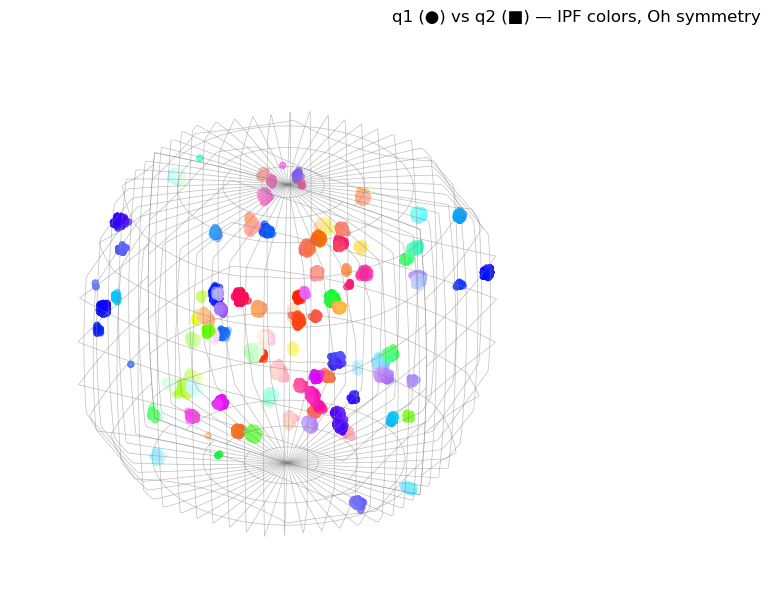

In [50]:

# Interactive prompts with sensible defaults
npy_path = "/data/home/umang/Materials/Materials_data_mount/EBSD/IN718_FZ_2D_SR_x4/Open718_QSR_x4/Test/Original_Data/Open_718_Test_hr_x_block_0.npy"
default_out = "debug_fz"
default_sym = "Oh"
default_max_samples = None

print("Loading:", npy_path)
q_xyzw = np.load(npy_path)
H, W, C = q_xyzw.shape
assert C == 4, "Expected (H,W,4) XYZW input"

q_wxyz = xyzw_to_wxyz(q_xyzw)


ori = Orientation(q_wxyz.reshape(-1,4), symmetry=Oh)
ckey = IPFColorKeyTSL(Oh.laue)
ref_dirs = {'X': Vector3d.xvector(), 'Y': Vector3d.yvector(), 'Z': Vector3d.zvector()}
colors = {}
for name, vec in ref_dirs.items():
    ckey.direction = vec
    colors[name] = ckey.orientation2color(ori)

fig = plt.figure(figsize=(12, 6))

ori.scatter(projection='axangle', figure=fig, position=(1, 2, 1), c=colors['Z'])
# Orientation(ori[1].data, symmetry=Oh).scatter(projection='axangle', figure=fig, position=(1, 2, 2), c=colors['Z'][1])

# Orientation(ori[0].data, symmetry=Oh).scatter(projection='axangle', figure=fig, position=(1, 2, 1), c=colors['Z'][0])
# Orientation(ori[1].data, symmetry=Oh).scatter(projection='axangle', figure=fig, position=(1, 2, 2), c=colors['Z'][1])
plt.suptitle('q1 (●) vs q2 (■) — IPF colors, Oh symmetry', y=1.01)
plt.tight_layout()
plt.show()

Loading: /data/home/umang/Materials/Materials_data_mount/EBSD/IN718_FZ_2D_SR_x4/Open718_QSR_x4/Test/Original_Data/Open_718_Test_hr_x_block_0.npy


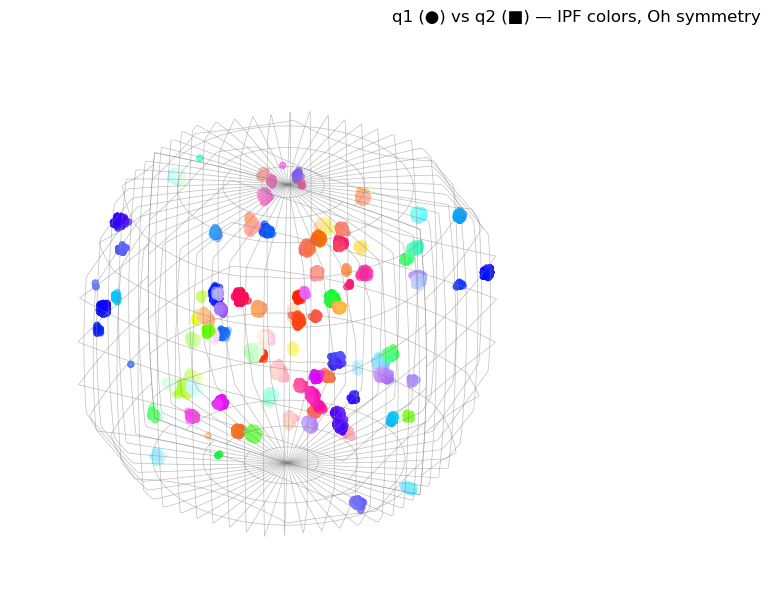

In [51]:
from orix.quaternion import symmetry as SYM

# Interactive prompts with sensible defaults
npy_path = "/data/home/umang/Materials/Materials_data_mount/EBSD/IN718_FZ_2D_SR_x4/Open718_QSR_x4/Test/Original_Data/Open_718_Test_hr_x_block_0.npy"
default_out = "debug_fz"
default_sym = "Oh"
default_max_samples = None


print("Loading:", npy_path)
q_xyzw = np.load(npy_path)
H, W, C = q_xyzw.shape
assert C == 4, "Expected (H,W,4) XYZW input"

q_wxyz = xyzw_to_wxyz(q_xyzw)

# ---------------------------------------------------------------------------
#  --- Oh symmetry operators (48 ops, Laue group) in [w,x,y,z] ---
# ---------------------------------------------------------------------------
oh_ops_np = np.asarray(SYM.Oh.data, dtype=np.float32)     # (48, 4)
oh_ops     = torch.from_numpy(oh_ops_np)                   # (48, 4)
# Unit-quaternion inverse = conjugate: negate xyz
oh_ops_inv = oh_ops.clone()
oh_ops_inv[:, 1:] *= -1.0                                  # (48, 4)
oh_ops_inv = oh_ops_inv[:24]


q_wxyz_fz_reduced = reduce_to_fz_oh_image(q_wxyz,oh_ops_inv)

ori = Orientation(q_wxyz_fz_reduced.reshape(-1,4), symmetry=Oh)
ckey = IPFColorKeyTSL(Oh.laue)

ref_dirs = {'X': Vector3d.xvector(), 'Y': Vector3d.yvector(), 'Z': Vector3d.zvector()}
colors = {}
for name, vec in ref_dirs.items():
    ckey.direction = vec
    colors[name] = ckey.orientation2color(ori)

fig = plt.figure(figsize=(12, 6))

ori.scatter(projection='axangle', figure=fig, position=(1, 2, 1), c=colors['Z'])

plt.suptitle('q1 (●) vs q2 (■) — IPF colors, Oh symmetry', y=1.01)
plt.tight_layout()
plt.show()